In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Shape",df.shape)
print("\nColumns:\n",df.columns.to_list())
print("\nData types:\n",df.dtypes)
print("\nMissing values:\n",df.isnull().sum())

Shape (7043, 21)

Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
 customerID    

In [5]:
# TotalCharges ko numeric banane ki koshish, errors ko track karo
df['TotalCharges_numeric'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Kitni rows fail hui (NaN ban gayi)
print("Hidden missing values:", df['TotalCharges_numeric'].isnull().sum())

# Wo rows dikhao jo problem create kar rahi hain
df[df['TotalCharges_numeric'].isnull()][['customerID', 'tenure', 'TotalCharges']]

Hidden missing values: 11


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


In [6]:
# Real TotalCharges column ko fix karo (purani string wali ko replace)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Ye 11 rows fill karo with 0 (kyunki tenure 0 hai, total charges bhi 0 hi honi chahiye)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Helper column delete kar do, ab zaroorat nahi
df.drop('TotalCharges_numeric', axis=1, inplace=True)

# Confirm karo ab sab clean hai
print(df['TotalCharges'].isnull().sum())
print(df.dtypes['TotalCharges'])

0
float64


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_1687/4163273207.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['#2ecc71', '#e74c3c'])


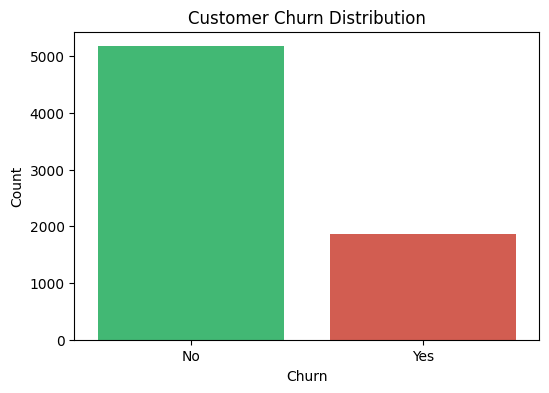

In [7]:
# Churn ka count aur percentage
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

# Graph banao
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

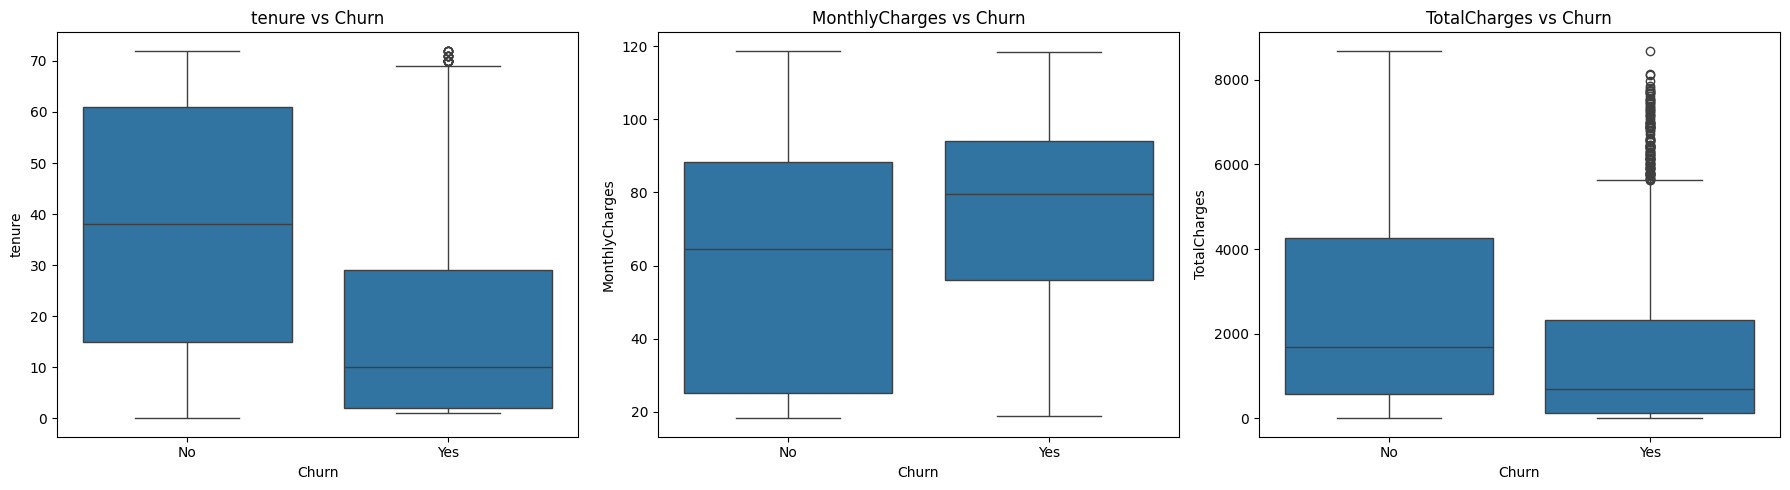

In [8]:
# Numerical columns vs Churn
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

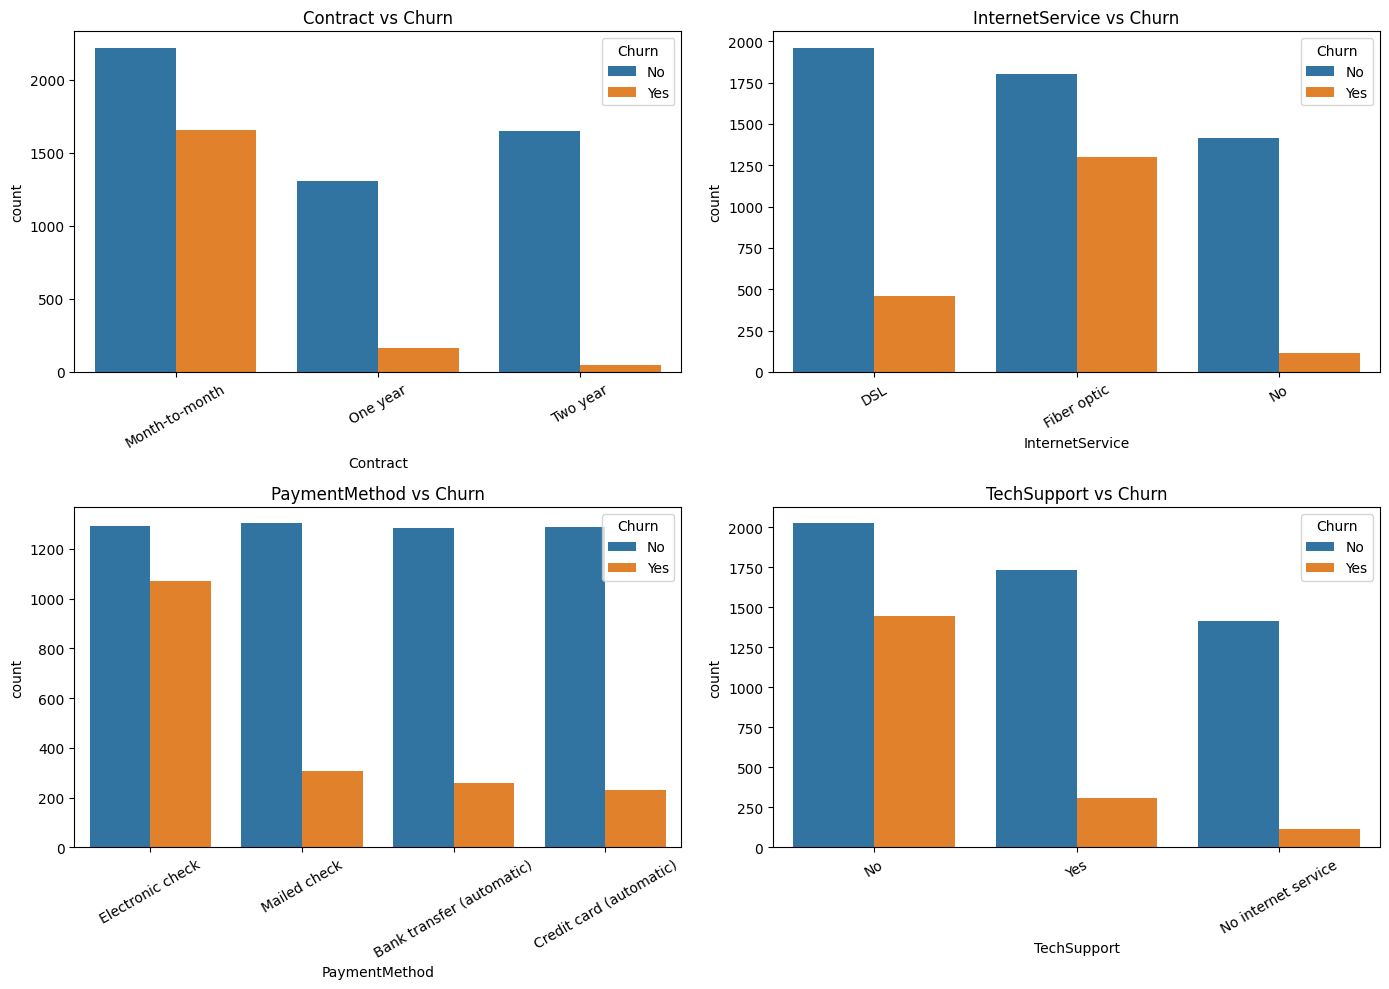

In [9]:
categorical_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [10]:
# customerID drop karo - ye sirf identifier hai, pattern nahi deta
df_model = df.drop('customerID', axis=1)

# Target variable ko encode karo: Yes=1, No=0
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [11]:
# Saare categorical (object type) columns identify karo
categorical_features = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_features)

# One-hot encoding apply karo
df_encoded = pd.get_dummies(df_model, columns=categorical_features, drop_first=True)

print("Shape before encoding:", df_model.shape)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape before encoding: (7043, 20)
Shape after encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [12]:
from sklearn.model_selection import train_test_split

# Features (X) aur Target (y) alag karo
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain Churn distribution:\n", y_train.value_counts(normalize=True))
print("\nTest Churn distribution:\n", y_test.value_counts(normalize=True))

Train shape: (5634, 30)
Test shape: (1409, 30)

Train Churn distribution:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test Churn distribution:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_smote.value_counts())
print("\nNew train shape:", X_train_smote.shape)

Before SMOTE: Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE: Churn
0    4139
1    4139
Name: count, dtype: int64

New train shape: (8278, 30)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit sirf training data pe, transform dono pe
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print(X_train_scaled[:2])  # pehli 2 rows dekho

Scaled train shape: (8278, 30)
[[-0.39535648  0.28980999 -0.66229638 -0.17447362  0.86288657 -1.01142061
  -0.64086045 -3.39462064  2.90129625 -0.97777766 -1.08634351 -0.45251927
  -0.45251927 -0.63711092 -0.45251927 -0.7767441  -0.45251927  1.28643188
  -0.45251927 -0.63861031 -0.45251927  1.09377262 -0.45251927  1.10341263
  -0.48492647 -0.46736284 -1.50686563 -0.52825014  1.03717269 -0.55548881]
 [-0.39535648 -0.54299005  0.23870597 -0.42419427  0.86288657  0.98870835
   1.56040212  0.29458373 -0.34467352 -0.97777766  0.92051915 -0.45251927
  -0.45251927  1.5695854  -0.45251927 -0.7767441  -0.45251927 -0.77734392
  -0.45251927 -0.63861031 -0.45251927 -0.9142668  -0.45251927 -0.90627928
  -0.48492647 -0.46736284 -1.50686563 -0.52825014 -0.9641596   1.80021629]]


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model 1: Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train_smote)

# Model 2: Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train_smote)

# Model 3: XGBoost
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train_smote)

print("Teeno models train ho gaye!")

Teeno models train ho gaye!


In [16]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    results[name] = roc_auc

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1035
           1       0.54      0.63      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.76      0.77      1409

ROC-AUC Score: 0.8127
Confusion Matrix:
 [[836 199]
 [137 237]]

Model: Random Forest
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1035
           1       0.56      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409

ROC-AUC Score: 0.8202
Confusion Matrix:
 [[865 170]
 [154 220]]

Model: XGBoost
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1035
           1       0.55      0.57      0.56

                           Feature  Importance
3                     TotalCharges    0.168362
1                           tenure    0.153748
2                   MonthlyCharges    0.135451
28  PaymentMethod_Electronic check    0.103156
10     InternetService_Fiber optic    0.055585
26            PaperlessBilling_Yes    0.040859
25               Contract_Two year    0.037810
4                      gender_Male    0.023610
9                MultipleLines_Yes    0.021759
24               Contract_One year    0.020584


/tmp/ipykernel_1687/363734467.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')


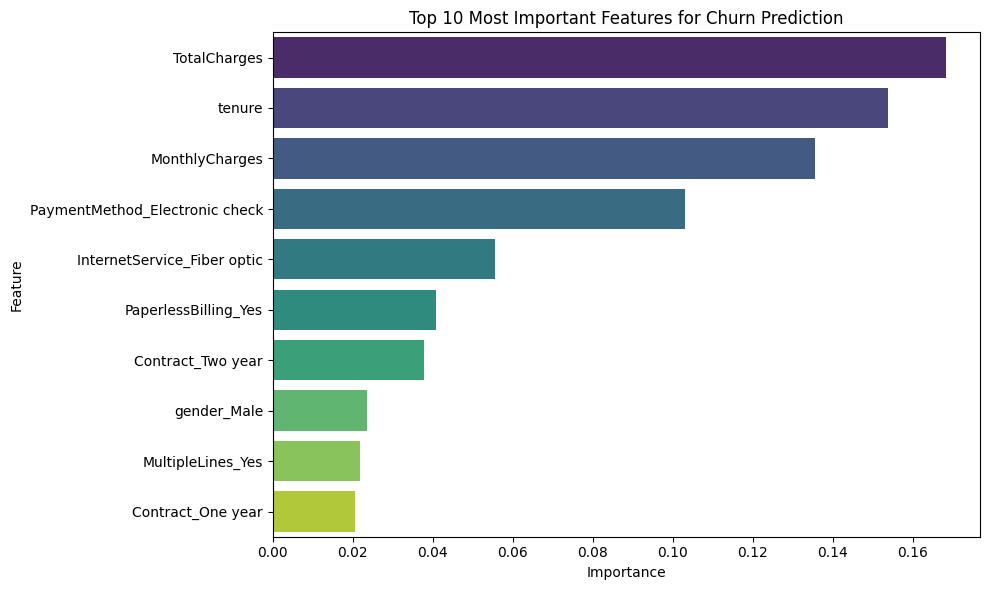

In [17]:
import pandas as pd

# Feature importance nikalo Random Forest se
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(10))

# Graph banao
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')
plt.title('Top 10 Most Important Features for Churn Prediction')
plt.tight_layout()
plt.show()

In [18]:
import joblib

# Best model (Logistic Regression) aur scaler dono save karo
joblib.dump(lr_model, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Column names bhi save karo (Streamlit app ko pata hona chahiye kaunse columns chahiye)
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

print("Model, scaler, aur columns save ho gaye!")

Model, scaler, aur columns save ho gaye!
